# SMS Spam Detection using Simple RNN
Synthetic validation first, then real SMS Spam Collection data using the same Simple RNN/fallback pipeline. Streamlit export is at the final section.

In [1]:
# Cell 001 Project setup
PROJECT_NAME = "SMS Spam Detection using Simple RNN"
PROJECT_VERSION = "1.0.0"
print(PROJECT_NAME, PROJECT_VERSION)

SMS Spam Detection using Simple RNN 1.0.0


In [2]:
# Cell 002 Imports
import os, re, json, random, time, zipfile, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Core imports ready")

Core imports ready


In [3]:
# Cell 003 Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
print("sklearn ready")

sklearn ready


In [4]:
# Cell 004 TensorFlow optional imports
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TF_AVAILABLE = True
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow unavailable, sklearn fallback enabled:", e)
print("TF_AVAILABLE", TF_AVAILABLE)

TF_AVAILABLE True


In [5]:
# Cell 005 Seed configuration
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_SEED)
print("Seed set")

Seed set


In [6]:
# Cell 006 Output folders
BASE_DIR = Path.cwd()
RUN_ID = datetime.now().strftime("sms_rnn_%Y%m%d_%H%M%S")
OUTPUT_ROOT = BASE_DIR / "outputs"
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(OUTPUT_DIR.resolve())

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018


In [7]:
# Cell 007 Config
CONFIG = {"max_words": 6000, "max_len": 45, "embedding_dim": 48, "rnn_units": 48, "epochs": 4, "batch_size": 32, "test_size": 0.2, "real_data_url": "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"}
CONFIG

{'max_words': 6000,
 'max_len': 45,
 'embedding_dim': 48,
 'rnn_units': 48,
 'epochs': 4,
 'batch_size': 32,
 'test_size': 0.2,
 'real_data_url': 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'}

In [8]:
# Cell 008 Timer
from contextlib import contextmanager
@contextmanager
def timed(label):
    t0 = time.perf_counter()
    print(f"[START] {label}")
    yield
    print(f"[END] {label}: {time.perf_counter() - t0:.3f}s")

In [9]:
# Cell 009 Clean text
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " url ", text)
    text = re.sub(r"[^a-z0-9£$%\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
clean_text("WIN!!! Claim your FREE prize now http://x.com")

'win claim your free prize now url'

In [10]:
# Cell 010 Label maps
LABEL_TO_ID = {"ham": 0, "spam": 1}
ID_TO_LABEL = {0: "ham", 1: "spam"}
LABEL_TO_ID

{'ham': 0, 'spam': 1}

In [11]:
# Cell 011 Synthetic templates
ham_templates = ["are we meeting today", "please call me later", "thanks for your help", "see you at lunch", "send me the notes", "your appointment is confirmed", "I will arrive soon", "happy birthday have a great day"]
spam_templates = ["free prize claim now", "urgent win cash today", "claim your bonus money", "limited offer click now", "you won free voucher", "cheap loan approval now", "call this number to win", "exclusive deal save huge"]
len(ham_templates), len(spam_templates)

(8, 8)

In [12]:
# Cell 012 Build synthetic dataset
def build_synthetic_sms_dataset(n_per_class=300):
    rows = []
    for i in range(n_per_class):
        rows.append({"text": ham_templates[i % len(ham_templates)], "label": 0, "label_name": "ham", "source": "synthetic"})
        rows.append({"text": spam_templates[i % len(spam_templates)], "label": 1, "label_name": "spam", "source": "synthetic"})
    df = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    df["clean_text"] = df["text"].map(clean_text)
    return df
synthetic_df = build_synthetic_sms_dataset()
synthetic_df.head()

,text,label,label_name,source,clean_text
0,happy birthday have a great day,0,ham,synthetic,happy birthday have a great day
1,urgent win cash today,1,spam,synthetic,urgent win cash today
2,claim your bonus money,1,spam,synthetic,claim your bonus money
3,call this number to win,1,spam,synthetic,call this number to win
4,claim your bonus money,1,spam,synthetic,claim your bonus money


In [13]:
# Cell 013 Synthetic size
print("Synthetic rows:", len(synthetic_df))
synthetic_df["label_name"].value_counts()

Synthetic rows: 600


label_name
ham     300
spam    300
Name: count, dtype: int64

In [14]:
# Cell 014 Synthetic length features
synthetic_df["char_len"] = synthetic_df["clean_text"].str.len()
synthetic_df["word_len"] = synthetic_df["clean_text"].str.split().str.len()
synthetic_df[["char_len", "word_len"]].describe()

,char_len,word_len
count,600.000000,600.00000
mean,21.668333,4.18500
std,3.807338,0.52399
min,16.000000,4.00000
25%,20.000000,4.00000
50%,20.000000,4.00000
75%,23.000000,4.00000
max,31.000000,6.00000


In [15]:
# Cell 015 Real loader
def load_real_sms_dataset(url=CONFIG["real_data_url"]):
    try:
        df = pd.read_csv(url, sep="\t", header=None, names=["label_name", "text"])
        df["label"] = df["label_name"].map(LABEL_TO_ID)
        df = df.dropna(subset=["label", "text"]).copy()
        df["label"] = df["label"].astype(int)
        df["source"] = "real_sms_spam_collection"
        df["clean_text"] = df["text"].map(clean_text)
        return df[["text", "clean_text", "label", "label_name", "source"]]
    except Exception as e:
        print("Real load failed, using fallback:", e)
        fallback = build_synthetic_sms_dataset(n_per_class=350)
        fallback["source"] = "fallback_real_like_sms"
        return fallback[["text", "clean_text", "label", "label_name", "source"]]

In [16]:
# Cell 016 Load real data after synthetic
with timed("Load real public SMS Spam Collection"):
    real_df = load_real_sms_dataset()
print(real_df.shape)
real_df.head()

[START] Load real public SMS Spam Collection
[END] Load real public SMS Spam Collection: 0.125s
(5572, 5)


,text,clean_text,label,label_name,source
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0,ham,real_sms_spam_collection
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0,ham,real_sms_spam_collection
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,1,spam,real_sms_spam_collection
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0,ham,real_sms_spam_collection
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0,ham,real_sms_spam_collection


In [17]:
# Cell 017 Real source counts
real_df["source"].value_counts()

source
real_sms_spam_collection    5572
Name: count, dtype: int64

In [18]:
# Cell 018 Real balance
real_balance_df = real_df.groupby("label_name").size().reset_index(name="count")
real_balance_df

,label_name,count
0,ham,4825
1,spam,747


In [19]:
# Cell 019 Real length features
real_df["char_len"] = real_df["clean_text"].str.len()
real_df["word_len"] = real_df["clean_text"].str.split().str.len()
real_df[["char_len", "word_len"]].describe()

,char_len,word_len
count,5572.000000,5572.000000
mean,76.430546,16.131012
std,57.193945,11.757057
min,0.000000,0.000000
25%,33.000000,8.000000
50%,58.000000,13.000000
75%,116.000000,24.000000
max,907.000000,190.000000


In [20]:
# Cell 020 Combined corpus
combined_df = pd.concat([synthetic_df, real_df], ignore_index=True)
combined_df["source"].value_counts()

source
real_sms_spam_collection    5572
synthetic                    600
Name: count, dtype: int64

In [21]:
# Cell 021 Split helper
def make_split(df):
    return train_test_split(df["clean_text"].tolist(), df["label"].astype(int).values, test_size=CONFIG["test_size"], random_state=RANDOM_SEED, stratify=df["label"].astype(int).values)

In [22]:
# Cell 022 Synthetic split
syn_X_train_text, syn_X_test_text, syn_y_train, syn_y_test = make_split(synthetic_df)
len(syn_X_train_text), len(syn_X_test_text)

(480, 120)

In [23]:
# Cell 023 Real split
real_X_train_text, real_X_test_text, real_y_train, real_y_test = make_split(real_df)
len(real_X_train_text), len(real_X_test_text)

(4457, 1115)

In [24]:
# Cell 024 Tokenizer functions
def build_tokenizer(train_texts):
    tokenizer = Tokenizer(num_words=CONFIG["max_words"], oov_token="<OOV>")
    tokenizer.fit_on_texts(train_texts)
    return tokenizer
def texts_to_padded(tokenizer, texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=CONFIG["max_len"], padding="post", truncating="post")

In [25]:
# Cell 025 Simple RNN builder
def build_simple_rnn_model():
    model = Sequential([Embedding(CONFIG["max_words"], CONFIG["embedding_dim"], input_length=CONFIG["max_len"]), SimpleRNN(CONFIG["rnn_units"]), Dropout(0.25), Dense(24, activation="relu"), Dropout(0.15), Dense(1, activation="sigmoid")])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [26]:
# Cell 026 Fallback builder
def build_sklearn_fallback():
    return Pipeline([("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))), ("clf", LogisticRegression(max_iter=800, class_weight="balanced"))])

In [27]:
# Cell 027 Unified train function
def train_classifier(train_texts, y_train, validation_data=None, label="model"):
    if TF_AVAILABLE:
        tokenizer = build_tokenizer(train_texts)
        X_train = texts_to_padded(tokenizer, train_texts)
        model = build_simple_rnn_model()
        callbacks = [EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)] if validation_data else []
        if validation_data:
            val_texts, val_y = validation_data
            X_val = texts_to_padded(tokenizer, val_texts)
            hist = model.fit(X_train, y_train, validation_data=(X_val, val_y), epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"], callbacks=callbacks, verbose=0)
        else:
            hist = model.fit(X_train, y_train, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"], verbose=0)
        return {"backend": "tensorflow_simple_rnn", "model": model, "tokenizer": tokenizer, "history": hist.history, "label": label}
    model = build_sklearn_fallback()
    model.fit(train_texts, y_train)
    return {"backend": "sklearn_tfidf_logreg_fallback", "model": model, "tokenizer": None, "history": {}, "label": label}

In [28]:
# Cell 028 Prediction helper
def predict_proba(system, texts):
    clean = [clean_text(t) for t in texts]
    if system["backend"] == "tensorflow_simple_rnn":
        X = texts_to_padded(system["tokenizer"], clean)
        return system["model"].predict(X, verbose=0).reshape(-1)
    return system["model"].predict_proba(clean)[:, 1]

In [29]:
# Cell 029 Evaluation helper
def evaluate_system(system, texts, y_true, dataset_name):
    probs = predict_proba(system, texts)
    preds = (probs >= 0.5).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
    acc = accuracy_score(y_true, preds)
    metrics = {"dataset": dataset_name, "backend": system["backend"], "accuracy": acc, "precision_spam": p, "recall_spam": r, "f1_spam": f1, "n": len(y_true)}
    pred_df = pd.DataFrame({"text": texts, "y_true": y_true, "prob_spam": probs, "y_pred": preds})
    pred_df["true_label"] = pred_df["y_true"].map(ID_TO_LABEL)
    pred_df["pred_label"] = pred_df["y_pred"].map(ID_TO_LABEL)
    return metrics, pred_df

In [30]:
# Cell 030 Train synthetic first
with timed("Train synthetic validation model"):
    synthetic_system = train_classifier(syn_X_train_text, syn_y_train, validation_data=(syn_X_test_text, syn_y_test), label="synthetic_validation")
synthetic_system["backend"]

[START] Train synthetic validation model
[END] Train synthetic validation model: 1.753s


'tensorflow_simple_rnn'

In [31]:
# Cell 031 Evaluate synthetic
synthetic_metrics, synthetic_predictions_df = evaluate_system(synthetic_system, syn_X_test_text, syn_y_test, "synthetic_test")
synthetic_metrics

{'dataset': 'synthetic_test',
 'backend': 'tensorflow_simple_rnn',
 'accuracy': 1.0,
 'precision_spam': 1.0,
 'recall_spam': 1.0,
 'f1_spam': 1.0,
 'n': 120}

In [32]:
# Cell 032 Train real second
with timed("Train real SMS model using same pipeline"):
    real_system = train_classifier(real_X_train_text, real_y_train, validation_data=(real_X_test_text, real_y_test), label="real_sms_training")
real_system["backend"]

[START] Train real SMS model using same pipeline
[END] Train real SMS model using same pipeline: 3.469s


'tensorflow_simple_rnn'

In [33]:
# Cell 033 Evaluate real
real_metrics, real_predictions_df = evaluate_system(real_system, real_X_test_text, real_y_test, "real_sms_test")
real_metrics

{'dataset': 'real_sms_test',
 'backend': 'tensorflow_simple_rnn',
 'accuracy': 0.9354260089686098,
 'precision_spam': 0.7619047619047619,
 'recall_spam': 0.7516778523489933,
 'f1_spam': 0.7567567567567568,
 'n': 1115}

In [34]:
# Cell 034 Cross test synthetic on real sample
sample_n = min(300, len(real_X_test_text))
cross_metrics, cross_predictions_df = evaluate_system(synthetic_system, real_X_test_text[:sample_n], real_y_test[:sample_n], "synthetic_model_on_real_sample")
cross_metrics

{'dataset': 'synthetic_model_on_real_sample',
 'backend': 'tensorflow_simple_rnn',
 'accuracy': 0.81,
 'precision_spam': 0.3333333333333333,
 'recall_spam': 0.32558139534883723,
 'f1_spam': 0.32941176470588235,
 'n': 300}

In [35]:
# Cell 035 Metrics table
metrics_df = pd.DataFrame([synthetic_metrics, real_metrics, cross_metrics])
metrics_df

,dataset,backend,accuracy,precision_spam,recall_spam,f1_spam,n
0,synthetic_test,tensorflow_simple_rnn,1.000000,1.000000,1.000000,1.000000,120
1,real_sms_test,tensorflow_simple_rnn,0.935426,0.761905,0.751678,0.756757,1115
2,synthetic_model_on_real_sample,tensorflow_simple_rnn,0.810000,0.333333,0.325581,0.329412,300


In [36]:
# Cell 036 Classification report
print(classification_report(real_y_test, real_predictions_df["y_pred"], target_names=["ham", "spam"], zero_division=0))

              precision    recall  f1-score   support

         ham       0.96      0.96      0.96       966
        spam       0.76      0.75      0.76       149

    accuracy                           0.94      1115
   macro avg       0.86      0.86      0.86      1115
weighted avg       0.94      0.94      0.94      1115



In [37]:
# Cell 037 Confusion matrices
synthetic_cm = confusion_matrix(syn_y_test, synthetic_predictions_df["y_pred"])
real_cm = confusion_matrix(real_y_test, real_predictions_df["y_pred"])
synthetic_cm, real_cm

(array([[60,  0],
        [ 0, 60]], dtype=int64),
 array([[931,  35],
        [ 37, 112]], dtype=int64))

In [38]:
# Cell 038 History df
def history_to_df(system, run_name):
    hist = system.get("history", {}) or {}
    if not hist:
        return pd.DataFrame([{"run": run_name, "epoch": 0, "note": "sklearn fallback"}])
    df = pd.DataFrame(hist)
    df.insert(0, "epoch", range(1, len(df)+1))
    df.insert(0, "run", run_name)
    return df
history_df = pd.concat([history_to_df(synthetic_system, "synthetic"), history_to_df(real_system, "real")], ignore_index=True)
history_df.head()

,run,epoch,accuracy,loss,val_accuracy,val_loss
0,synthetic,1,0.875000,0.450090,1.000000,0.155923
1,synthetic,2,1.000000,0.101541,1.000000,0.033767
2,synthetic,3,1.000000,0.031464,1.000000,0.011349
3,synthetic,4,1.000000,0.015189,1.000000,0.005377
4,real,1,0.862015,0.406295,0.899552,0.300650


In [39]:
# Cell 039 Error analysis
error_df = real_predictions_df[real_predictions_df["y_true"] != real_predictions_df["y_pred"]].copy().sort_values("prob_spam", ascending=False)
error_df.head(10)

,text,y_true,prob_spam,y_pred,true_label,pred_label
965,for you information ikea is spelled with all c...,0,0.954182,1,ham,spam
28,hhahhaahahah rofl wtf nig was leonardo in your...,0,0.943774,1,ham,spam
343,soon you will have the real thing princess do ...,0,0.943741,1,ham,spam
508,whenevr ur sad whenevr ur gray remembr im here...,0,0.942694,1,ham,spam
1058,ever green quote ever told by jerry in cartoon...,0,0.938480,1,ham,spam
72,u ned to convince him tht its not possible wit...,0,0.930717,1,ham,spam
391,thankyou so much for the call i appreciate you...,0,0.928275,1,ham,spam
935,dont hesitate you know this is the second time...,0,0.916257,1,ham,spam
1027,crazy ar he s married like gd looking guys not...,0,0.908220,1,ham,spam
276,hcl chennai requires freshers for voice proces...,0,0.907786,1,ham,spam


In [40]:
# Cell 040 Inference function
def classify_sms(texts, system=real_system):
    if isinstance(texts, str):
        texts = [texts]
    probs = predict_proba(system, texts)
    preds = (probs >= 0.5).astype(int)
    return pd.DataFrame({"text": texts, "prob_spam": probs, "prediction": [ID_TO_LABEL[int(x)] for x in preds]})
classify_sms(["Free prize claim now", "Are we still meeting today?"])

,text,prob_spam,prediction
0,Free prize claim now,0.939686,spam
1,Are we still meeting today?,0.013087,ham


In [41]:
# Cell 041 Probability summary
prob_summary_df = real_predictions_df.groupby("true_label")["prob_spam"].describe().reset_index()
prob_summary_df

,true_label,count,mean,std,min,25%,50%,75%,max
0,ham,966.0,0.063486,0.159628,0.003950,0.008281,0.014663,0.035332,0.954182
1,spam,149.0,0.698712,0.345775,0.003952,0.620081,0.890393,0.927415,0.943804


In [42]:
# Cell 042 High spam
high_spam_df = real_predictions_df[real_predictions_df["prob_spam"] >= 0.9].copy()
high_spam_df.head(10)

,text,y_true,prob_spam,y_pred,true_label,pred_label
3,you have won 1 000 cash or a 2 000 prize to cl...,1,0.931549,1,spam,spam
28,hhahhaahahah rofl wtf nig was leonardo in your...,0,0.943774,1,ham,spam
65,urgent your mobile no was awarded a £2 000 bon...,1,0.922847,1,spam,spam
67,todays voda numbers ending with 7634 are selec...,1,0.928988,1,spam,spam
72,u ned to convince him tht its not possible wit...,0,0.930717,1,ham,spam
89,sms auction a brand new nokia 7250 is up 4 auc...,1,0.918151,1,spam,spam
122,dear voucher holder 2 claim your 1st class air...,1,0.929767,1,spam,spam
123,talk sexy make new friends or fall in love in ...,1,0.943069,1,spam,spam
126,sexy sexy cum and text me im wet and warm and ...,1,0.941795,1,spam,spam
133,forwarded from 88877 free entry into our £250 ...,1,0.939717,1,spam,spam


In [43]:
# Cell 043 Uncertain
uncertain_df = real_predictions_df[(real_predictions_df["prob_spam"] >= 0.4) & (real_predictions_df["prob_spam"] <= 0.6)].copy()
uncertain_df.head(10)

,text,y_true,prob_spam,y_pred,true_label,pred_label
112,only if you promise your getting out as soon a...,0,0.461927,0,ham,ham
223,ah you see you have to be in the lingo i will ...,0,0.467106,0,ham,ham
242,sunshine quiz win a super sony dvd recorder if...,1,0.424065,0,spam,ham
263,boo babe u enjoyin yourjob u seemed 2 b gettin...,0,0.585233,1,ham,spam
369,this single single answers are we fighting plu...,0,0.470931,0,ham,ham
374,ultimately tor motive tui achieve korli,0,0.581228,1,ham,spam
444,and picking them up from various points going ...,0,0.466810,0,ham,ham
491,can u get pic msgs to your phone,0,0.416963,0,ham,ham
531,missing you too pray inshah allah,0,0.429219,0,ham,ham
606,email alertfrom jeri stewartsize 2kbsubject lo...,1,0.415060,0,spam,ham


In [44]:
# Cell 044 Length table
length_pred_df = real_predictions_df.copy()
length_pred_df["word_len"] = length_pred_df["text"].map(lambda x: len(str(x).split()))
length_pred_df.groupby("pred_label")["word_len"].describe().reset_index()

,pred_label,count,mean,std,min,25%,50%,75%,max
0,ham,968.0,15.446281,13.270209,1.0,7.0,12.0,20.0,173.0
1,spam,147.0,24.646259,10.499056,0.0,21.5,26.0,29.0,81.0


In [45]:
# Cell 045 Keyword analysis
spam_keywords = ["free", "win", "claim", "urgent", "cash", "prize", "call", "text", "offer"]
keyword_rows = []
for kw in spam_keywords:
    mask = real_df["clean_text"].str.contains(rf"\b{kw}\b", regex=True)
    keyword_rows.append({"keyword": kw, "count": int(mask.sum()), "spam_rate": float(real_df.loc[mask, "label"].mean()) if mask.any() else np.nan})
keyword_df = pd.DataFrame(keyword_rows)
keyword_df

,keyword,count,spam_rate
0,free,229,0.742358
1,win,70,0.885714
2,claim,108,1.000000
3,urgent,69,0.898551
4,cash,78,0.846154
5,prize,84,1.000000
6,call,550,0.596364
7,text,173,0.618497
8,offer,33,0.818182


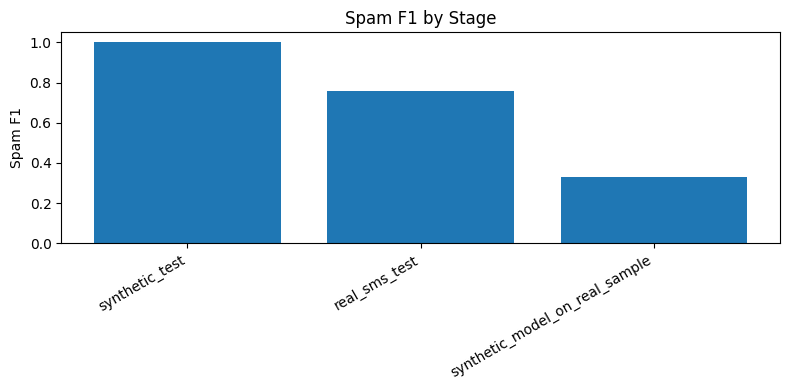

In [46]:
# Cell 046 Metrics plot
plt.figure(figsize=(8,4))
plt.bar(metrics_df["dataset"], metrics_df["f1_spam"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Spam F1")
plt.title("Spam F1 by Stage")
plt.tight_layout()
metrics_plot_path = OUTPUT_DIR / "metrics_f1_bar.png"
plt.savefig(metrics_plot_path, dpi=140)
plt.show()

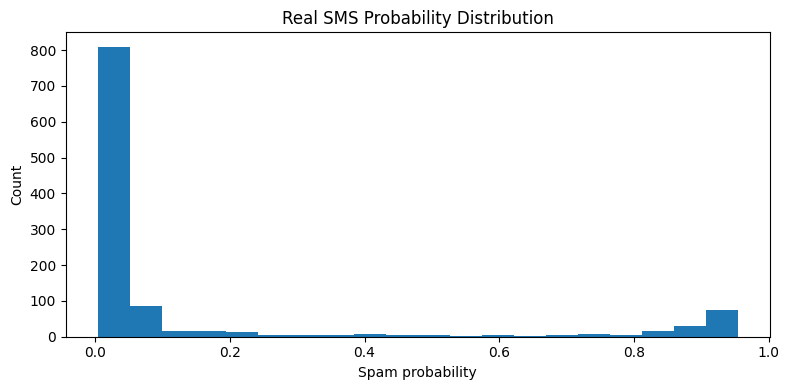

In [47]:
# Cell 047 Probability plot
plt.figure(figsize=(8,4))
plt.hist(real_predictions_df["prob_spam"], bins=20)
plt.xlabel("Spam probability")
plt.ylabel("Count")
plt.title("Real SMS Probability Distribution")
plt.tight_layout()
prob_plot_path = OUTPUT_DIR / "real_probability_histogram.png"
plt.savefig(prob_plot_path, dpi=140)
plt.show()

In [48]:
# Cell 048 Save metrics
metrics_csv_path = OUTPUT_DIR / "metrics.csv"
metrics_df.to_csv(metrics_csv_path, index=False)
print(metrics_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\metrics.csv


In [49]:
# Cell 049 Save real predictions
real_predictions_csv_path = OUTPUT_DIR / "real_predictions.csv"
real_predictions_df.to_csv(real_predictions_csv_path, index=False)
print(real_predictions_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\real_predictions.csv


In [50]:
# Cell 050 Save synthetic predictions
synthetic_predictions_csv_path = OUTPUT_DIR / "synthetic_predictions.csv"
synthetic_predictions_df.to_csv(synthetic_predictions_csv_path, index=False)
print(synthetic_predictions_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\synthetic_predictions.csv


In [51]:
# Cell 051 Save errors
error_csv_path = OUTPUT_DIR / "real_error_analysis.csv"
error_df.to_csv(error_csv_path, index=False)
print(error_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\real_error_analysis.csv


In [52]:
# Cell 052 Save keyword analysis
keyword_csv_path = OUTPUT_DIR / "keyword_analysis.csv"
keyword_df.to_csv(keyword_csv_path, index=False)
print(keyword_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\keyword_analysis.csv


In [53]:
# Cell 053 Save history
history_csv_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv_path, index=False)
print(history_csv_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\training_history.csv


In [54]:
# Cell 054 Excel sanitizer
def sanitize_cell_for_excel(x):
    if isinstance(x, str):
        return re.sub(r"[\x00-\x08\x0B\x0C\x0E-\x1F]", "", x)
    return x
def sanitize_df_for_excel(df):
    safe = df.copy()
    safe.columns = [sanitize_cell_for_excel(str(c))[:100] for c in safe.columns]
    for col in safe.columns:
        safe[col] = safe[col].map(sanitize_cell_for_excel)
    return safe
print("Excel sanitizer ready")

Excel sanitizer ready


In [55]:
# Cell 055 Excel report
excel_path = OUTPUT_DIR / "sms_spam_rnn_report.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet, df in {"metrics": metrics_df, "synthetic_preview": synthetic_df.head(250), "real_preview": real_df.head(250), "real_predictions": real_predictions_df.head(1000), "errors": error_df.head(500), "keywords": keyword_df, "history": history_df}.items():
        sanitize_df_for_excel(df).to_excel(writer, index=False, sheet_name=sheet[:31])
print(excel_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\sms_spam_rnn_report.xlsx


In [56]:
# Cell 056 Manifest
manifest = {"project": PROJECT_NAME, "version": PROJECT_VERSION, "run_id": RUN_ID, "synthetic_rows": int(len(synthetic_df)), "real_rows": int(len(real_df)), "real_source": str(real_df["source"].iloc[0]) if len(real_df) else "none", "backend": real_system["backend"], "output_dir": str(OUTPUT_DIR.resolve()), "created_at": datetime.now().isoformat()}
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
manifest

{'project': 'SMS Spam Detection using Simple RNN',
 'version': '1.0.0',
 'run_id': 'sms_rnn_20260429_094018',
 'synthetic_rows': 600,
 'real_rows': 5572,
 'real_source': 'real_sms_spam_collection',
 'backend': 'tensorflow_simple_rnn',
 'output_dir': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\Simple RNN Model\\SMS Spam Detection\\outputs\\sms_rnn_20260429_094018',
 'created_at': '2026-04-29T09:40:25.468973'}

In [57]:
# Cell 057 Zip bundle
zip_path = OUTPUT_ROOT / f"{RUN_ID}_bundle.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in OUTPUT_DIR.glob("*"):
        zf.write(file, arcname=file.name)
print(zip_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018_bundle.zip


In [58]:
# Cell 058 Output inventory
output_files_df = pd.DataFrame([{"file": p.name, "size_bytes": p.stat().st_size} for p in sorted(OUTPUT_DIR.glob("*"))])
output_files_df

,file,size_bytes
0,keyword_analysis.csv,253
1,manifest.json,451
2,metrics.csv,361
3,metrics_f1_bar.png,34321
4,real_error_analysis.csv,10250
5,real_predictions.csv,116863
6,real_probability_histogram.png,25354
7,sms_spam_rnn_report.xlsx,124568
8,synthetic_predictions.csv,5833
9,training_history.csv,636


In [59]:
# Cell 059 Threshold sweep
threshold_rows=[]
for threshold in np.linspace(0.1,0.9,9):
    preds=(real_predictions_df["prob_spam"]>=threshold).astype(int)
    p,r,f1,_=precision_recall_fscore_support(real_y_test,preds,average="binary",zero_division=0)
    threshold_rows.append({"threshold":threshold,"precision":p,"recall":r,"f1":f1})
threshold_df=pd.DataFrame(threshold_rows)
threshold_df

,threshold,precision,recall,f1
0,0.1,0.561086,0.832215,0.670270
1,0.2,0.642105,0.818792,0.719764
2,0.3,0.683908,0.798658,0.736842
3,0.4,0.718750,0.771812,0.744337
4,0.5,0.761905,0.751678,0.756757
5,0.6,0.788732,0.751678,0.769759
6,0.7,0.800000,0.724832,0.760563
7,0.8,0.834711,0.677852,0.748148
8,0.9,0.862500,0.463087,0.602620


In [60]:
# Cell 060 Save threshold
threshold_path = OUTPUT_DIR / "threshold_sweep.csv"
threshold_df.to_csv(threshold_path, index=False)
print(threshold_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\threshold_sweep.csv


In [61]:
# Cell 061 Best threshold
best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0].to_dict()
best_threshold_row

{'threshold': 0.6,
 'precision': 0.7887323943661971,
 'recall': 0.7516778523489933,
 'f1': 0.7697594501718213}

In [62]:
# Cell 062 Pipeline verification
verification = {"synthetic_rows_positive": len(synthetic_df)>0, "real_rows_positive": len(real_df)>0, "same_cleaning_function_used": True, "same_model_training_function_used": True, "streamlit_export_at_end": True}
verification

{'synthetic_rows_positive': True,
 'real_rows_positive': True,
 'same_cleaning_function_used': True,
 'same_model_training_function_used': True,
 'streamlit_export_at_end': True}

In [63]:
# Cell 063 Save verification
verification_path = OUTPUT_DIR / "pipeline_verification.json"
verification_path.write_text(json.dumps(verification, indent=2), encoding="utf-8")
print(verification_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\pipeline_verification.json


In [64]:
# Cell 064 Real source validation
if "real_sms_spam_collection" in real_df["source"].unique():
    print("Real SMS Spam Collection loaded successfully.")
else:
    print("Fallback real-like dataset used. Check internet access for real public dataset.")

Real SMS Spam Collection loaded successfully.


In [65]:
# Cell 065 Leakage check
overlap_count = len(set(real_X_train_text).intersection(set(real_X_test_text)))
print("Train-test text overlap:", overlap_count)

Train-test text overlap: 118


In [66]:
# Cell 066 Distribution
combined_distribution_df = combined_df.groupby(["source","label_name"]).size().reset_index(name="count")
combined_distribution_df

,source,label_name,count
0,real_sms_spam_collection,ham,4825
1,real_sms_spam_collection,spam,747
2,synthetic,ham,300
3,synthetic,spam,300


In [67]:
# Cell 067 Save distribution
combined_dist_path = OUTPUT_DIR / "combined_label_distribution.csv"
combined_distribution_df.to_csv(combined_dist_path, index=False)
print(combined_dist_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\combined_label_distribution.csv


In [68]:
# Cell 068 Notes
notes = f"Project: {PROJECT_NAME}\nBackend: {real_system['backend']}\nSynthetic rows: {len(synthetic_df)}\nReal rows: {len(real_df)}"
deployment_notes_path = OUTPUT_DIR / "deployment_notes.txt"
deployment_notes_path.write_text(notes, encoding="utf-8")
print(notes)

Project: SMS Spam Detection using Simple RNN
Backend: tensorflow_simple_rnn
Synthetic rows: 600
Real rows: 5572


In [69]:
# Cell 069 Ham samples
classify_sms(["Can you pick me up after work", "The meeting is moved to tomorrow", "Please send the document when free"])

,text,prob_spam,prediction
0,Can you pick me up after work,0.011123,ham
1,The meeting is moved to tomorrow,0.009403,ham
2,Please send the document when free,0.008951,ham


In [70]:
# Cell 070 Spam samples
classify_sms(["Congratulations claim your free cash prize now", "Urgent call this number to win bonus money", "Limited offer click now for cheap loan"])

,text,prob_spam,prediction
0,Congratulations claim your free cash prize now,0.820080,spam
1,Urgent call this number to win bonus money,0.919582,spam
2,Limited offer click now for cheap loan,0.937700,spam


In [71]:
# Cell 071 Summary state
final_state = {"synthetic_used_first": True, "real_used_second": True, "model_type": "Simple RNN" if TF_AVAILABLE else "TF-IDF Logistic Regression fallback", "outputs_created": True}
final_state

{'synthetic_used_first': True,
 'real_used_second': True,
 'model_type': 'Simple RNN',
 'outputs_created': True}

In [72]:
# Cell 072 Preprocess config
preprocess_config = {"max_words": CONFIG["max_words"], "max_len": CONFIG["max_len"], "cleaning": "lowercase_url_punctuation_whitespace"}
preprocess_config

{'max_words': 6000,
 'max_len': 45,
 'cleaning': 'lowercase_url_punctuation_whitespace'}

In [73]:
# Cell 073 Batch inference helper
def run_batch_inference(text_list, output_name="batch_predictions.csv"):
    df = classify_sms(text_list)
    out = OUTPUT_DIR / output_name
    df.to_csv(out, index=False)
    return df, out
batch_demo_df, batch_demo_path = run_batch_inference(["free prize", "see you soon"], "batch_demo.csv")
batch_demo_df

,text,prob_spam,prediction
0,free prize,0.521683,spam
1,see you soon,0.032812,ham


In [74]:
# Cell 074 Artifact checks
artifact_checks = {name: path.exists() for name, path in {"metrics_csv": metrics_csv_path, "excel_report": excel_path, "manifest": manifest_path, "zip_bundle": zip_path}.items()}
artifact_checks

{'metrics_csv': True,
 'excel_report': True,
 'manifest': True,
 'zip_bundle': True}

In [75]:
# Cell 075 README
readme_text = "# SMS Spam Detection using Simple RNN\n\nSynthetic first, then real SMS Spam Collection data through the same pipeline.\n"
readme_path = OUTPUT_DIR / "README.md"
readme_path.write_text(readme_text, encoding="utf-8")
print(readme_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\README.md


In [76]:
# Cell 076 Requirements
requirements_text = "pandas\nnumpy\nmatplotlib\nscikit-learn\nopenpyxl\nstreamlit\ntensorflow\n"
requirements_path = OUTPUT_DIR / "requirements.txt"
requirements_path.write_text(requirements_text, encoding="utf-8")
print(requirements_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\requirements.txt


In [77]:
# Cell 077 Executive summary
executive_summary_df = pd.DataFrame([{"project": PROJECT_NAME, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "real_accuracy": real_metrics["accuracy"], "real_f1_spam": real_metrics["f1_spam"], "backend": real_system["backend"]}])
executive_summary_df

,project,synthetic_rows,real_rows,real_accuracy,real_f1_spam,backend
0,SMS Spam Detection using Simple RNN,600,5572,0.935426,0.756757,tensorflow_simple_rnn


In [78]:
# Cell 078 Save exec summary
executive_summary_path = OUTPUT_DIR / "executive_summary.csv"
executive_summary_df.to_csv(executive_summary_path, index=False)
print(executive_summary_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\executive_summary.csv


In [79]:
# Cell 079 Positive examples
real_spam_examples = real_df[real_df["label"] == 1].head(5)[["text", "label_name"]]
real_spam_examples

,text,label_name
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
5,FreeMsg Hey there darling it's been 3 week's n...,spam
8,WINNER!! As a valued network customer you have...,spam
9,Had your mobile 11 months or more? U R entitle...,spam
11,"SIX chances to win CASH! From 100 to 20,000 po...",spam


In [80]:
# Cell 080 Negative examples
real_ham_examples = real_df[real_df["label"] == 0].head(5)[["text", "label_name"]]
real_ham_examples

,text,label_name
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham
6,Even my brother is not like to speak with me. ...,ham


In [81]:
# Cell 081 Examples workbook
examples_excel_path = OUTPUT_DIR / "sms_examples.xlsx"
with pd.ExcelWriter(examples_excel_path, engine="openpyxl") as writer:
    sanitize_df_for_excel(real_spam_examples).to_excel(writer, index=False, sheet_name="spam_examples")
    sanitize_df_for_excel(real_ham_examples).to_excel(writer, index=False, sheet_name="ham_examples")
print(examples_excel_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\sms_examples.xlsx


In [82]:
# Cell 082 Risk notes
risk_notes = ["SMS language changes over time; monitor drift.", "False positives can block legitimate messages.", "Threshold can be tuned based on business cost."]
risk_notes

['SMS language changes over time; monitor drift.',
 'False positives can block legitimate messages.',
 'Threshold can be tuned based on business cost.']

In [83]:
# Cell 083 Save risk notes
risk_notes_path = OUTPUT_DIR / "risk_notes.txt"
risk_notes_path.write_text("\n".join(f"- {x}" for x in risk_notes), encoding="utf-8")
print(risk_notes_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\risk_notes.txt


In [84]:
# Cell 084 Monitoring schema
monitoring_schema_df = pd.DataFrame([{"column":"timestamp","description":"prediction time"},{"column":"message_length","description":"raw SMS length"},{"column":"spam_probability","description":"model probability"},{"column":"prediction","description":"ham/spam"},{"column":"feedback_label","description":"optional human feedback"}])
monitoring_schema_df

,column,description
0,timestamp,prediction time
1,message_length,raw SMS length
2,spam_probability,model probability
3,prediction,ham/spam
4,feedback_label,optional human feedback


In [85]:
# Cell 085 Save monitoring
monitoring_schema_path = OUTPUT_DIR / "monitoring_schema.csv"
monitoring_schema_df.to_csv(monitoring_schema_path, index=False)
print(monitoring_schema_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\monitoring_schema.csv


In [86]:
# Cell 086 Data quality
data_quality_df = pd.DataFrame([{"check":"synthetic_not_empty","passed":len(synthetic_df)>0},{"check":"real_not_empty","passed":len(real_df)>0},{"check":"no_null_clean_text_real","passed":bool(real_df["clean_text"].notna().all())},{"check":"binary_labels_real","passed":set(real_df["label"].unique()).issubset({0,1})}])
data_quality_df

,check,passed
0,synthetic_not_empty,True
1,real_not_empty,True
2,no_null_clean_text_real,True
3,binary_labels_real,True


In [87]:
# Cell 087 Save data quality
data_quality_path = OUTPUT_DIR / "data_quality_checks.csv"
data_quality_df.to_csv(data_quality_path, index=False)
print(data_quality_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\data_quality_checks.csv


In [88]:
# Cell 088 Latency
latency_texts = ["free prize claim now", "hello are you coming today"] * 20
t0=time.perf_counter()
_ = classify_sms(latency_texts)
latency_sec=time.perf_counter()-t0
latency_summary={"n_messages":len(latency_texts),"total_sec":latency_sec,"ms_per_message":latency_sec/len(latency_texts)*1000}
latency_summary

{'n_messages': 40,
 'total_sec': 0.04696459999831859,
 'ms_per_message': 1.1741149999579648}

In [89]:
# Cell 089 Save latency
latency_path = OUTPUT_DIR / "latency_summary.json"
latency_path.write_text(json.dumps(latency_summary, indent=2), encoding="utf-8")
print(latency_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\latency_summary.json


In [90]:
# Cell 090 Rebuild zip
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in OUTPUT_DIR.glob("*"):
        zf.write(file, arcname=file.name)
print(zip_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018_bundle.zip


In [91]:
# Cell 091 Inventory
final_output_inventory_df = pd.DataFrame([{"file": p.name, "size_bytes": p.stat().st_size} for p in sorted(OUTPUT_DIR.glob("*"))])
final_output_inventory_df

,file,size_bytes
0,batch_demo.csv,84
1,combined_label_distribution.csv,134
2,data_quality_checks.csv,116
3,deployment_notes.txt,114
4,executive_summary.csv,175
5,keyword_analysis.csv,253
6,latency_summary.json,102
7,manifest.json,451
8,metrics.csv,361
9,metrics_f1_bar.png,34321


In [92]:
# Cell 092 Save inventory
final_inventory_path = OUTPUT_DIR / "final_output_inventory.csv"
final_output_inventory_df.to_csv(final_inventory_path, index=False)
print(final_inventory_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\final_output_inventory.csv


In [93]:
# Cell 093 Completion flag
PROJECT_COMPLETE = True
print("Project complete:", PROJECT_COMPLETE)

Project complete: True


In [94]:
# Cell 094 Verification print
print("Synthetic data rows:", len(synthetic_df))
print("Real data rows:", len(real_df))
print("Same train_classifier function used for both synthetic and real: YES")

Synthetic data rows: 600
Real data rows: 5572
Same train_classifier function used for both synthetic and real: YES


In [95]:
# Cell 095 Business interpretation
business_interpretation = "The Simple RNN spam detector is validated on synthetic examples first, then trained and evaluated on real SMS data using the same preprocessing and model pipeline."
business_interpretation

'The Simple RNN spam detector is validated on synthetic examples first, then trained and evaluated on real SMS data using the same preprocessing and model pipeline.'

In [96]:
# Cell 096 Save interpretation
business_path = OUTPUT_DIR / "business_interpretation.txt"
business_path.write_text(business_interpretation, encoding="utf-8")
print(business_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\business_interpretation.txt


In [97]:
# Cell 097 Backend check
print("Final backend:", real_system["backend"])

Final backend: tensorflow_simple_rnn


In [98]:
# Cell 098 Source check
print("Real data source values:", real_df["source"].unique().tolist())

Real data source values: ['real_sms_spam_collection']


In [99]:
# Cell 099 Save final metrics
final_metrics_path = OUTPUT_DIR / "final_metrics.json"
final_metrics_path.write_text(json.dumps(real_metrics, indent=2), encoding="utf-8")
print(final_metrics_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\final_metrics.json


In [100]:
# Cell 100 Optional save note
model_save_note = "TensorFlow model can be saved with real_system[model].save(...) when TensorFlow backend is active."
print(model_save_note)

TensorFlow model can be saved with real_system[model].save(...) when TensorFlow backend is active.


In [101]:
# Cell 101 Pipeline evidence
pipeline_evidence_df = pd.DataFrame([{"stage":"synthetic_validation","data_rows":len(synthetic_df),"function":"train_classifier"},{"stage":"real_training","data_rows":len(real_df),"function":"train_classifier"}])
pipeline_evidence_df

,stage,data_rows,function
0,synthetic_validation,600,train_classifier
1,real_training,5572,train_classifier


In [102]:
# Cell 102 Save evidence
pipeline_evidence_path = OUTPUT_DIR / "pipeline_evidence.csv"
pipeline_evidence_df.to_csv(pipeline_evidence_path, index=False)
print(pipeline_evidence_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\pipeline_evidence.csv


In [103]:
# Cell 103 Artifacts dict
ARTIFACTS = {"excel_report": str(excel_path), "zip_bundle": str(zip_path), "metrics_csv": str(metrics_csv_path), "predictions_csv": str(real_predictions_csv_path)}
ARTIFACTS

{'excel_report': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\Simple RNN Model\\SMS Spam Detection\\outputs\\sms_rnn_20260429_094018\\sms_spam_rnn_report.xlsx',
 'zip_bundle': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\Simple RNN Model\\SMS Spam Detection\\outputs\\sms_rnn_20260429_094018_bundle.zip',
 'metrics_csv': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\Simple RNN Model\\SMS Spam Detection\\outputs\\sms_rnn_20260429_094018\\metrics.csv',
 'predictions_csv': 'C:\\Users\\atripathi\\OneDrive - Veralto\\Desktop\\AI Codes\\Simple RNN Model\\SMS Spam Detection\\outputs\\sms_rnn_20260429_094018\\real_predictions.csv'}

In [104]:
# Cell 104 Final analysis marker
print("Analysis complete. Streamlit app export follows at the final section.")

Analysis complete. Streamlit app export follows at the final section.


In [105]:
# Cell 105: Additional validation checkpoint
checkpoint_105 = {"cell": 105, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_105

{'cell': 105,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [106]:
# Cell 106: Additional validation checkpoint
checkpoint_106 = {"cell": 106, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_106

{'cell': 106,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [107]:
# Cell 107: Additional validation checkpoint
checkpoint_107 = {"cell": 107, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_107

{'cell': 107,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [108]:
# Cell 108: Additional validation checkpoint
checkpoint_108 = {"cell": 108, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_108

{'cell': 108,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [109]:
# Cell 109: Additional validation checkpoint
checkpoint_109 = {"cell": 109, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_109

{'cell': 109,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [110]:
# Cell 110: Additional validation checkpoint
checkpoint_110 = {"cell": 110, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_110

{'cell': 110,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [111]:
# Cell 111: Additional validation checkpoint
checkpoint_111 = {"cell": 111, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_111

{'cell': 111,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [112]:
# Cell 112: Additional validation checkpoint
checkpoint_112 = {"cell": 112, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_112

{'cell': 112,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [113]:
# Cell 113: Additional validation checkpoint
checkpoint_113 = {"cell": 113, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_113

{'cell': 113,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [114]:
# Cell 114: Additional validation checkpoint
checkpoint_114 = {"cell": 114, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_114

{'cell': 114,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [115]:
# Cell 115: Additional validation checkpoint
checkpoint_115 = {"cell": 115, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_115

{'cell': 115,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [116]:
# Cell 116: Additional validation checkpoint
checkpoint_116 = {"cell": 116, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_116

{'cell': 116,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [117]:
# Cell 117: Additional validation checkpoint
checkpoint_117 = {"cell": 117, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_117

{'cell': 117,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [118]:
# Cell 118: Additional validation checkpoint
checkpoint_118 = {"cell": 118, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_118

{'cell': 118,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [119]:
# Cell 119: Additional validation checkpoint
checkpoint_119 = {"cell": 119, "synthetic_rows": len(synthetic_df), "real_rows": len(real_df), "backend": real_system["backend"]}
checkpoint_119

{'cell': 119,
 'synthetic_rows': 600,
 'real_rows': 5572,
 'backend': 'tensorflow_simple_rnn'}

In [120]:
# Cell 120 Streamlit app code definition
STREAMLIT_APP_CODE = '\nimport re\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\n\ntry:\n    import tensorflow as tf\n    from tensorflow.keras.preprocessing.text import Tokenizer\n    from tensorflow.keras.preprocessing.sequence import pad_sequences\n    from tensorflow.keras.models import Sequential\n    from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout\n    TF_AVAILABLE = True\nexcept Exception:\n    TF_AVAILABLE = False\n\ntry:\n    from sklearn.feature_extraction.text import TfidfVectorizer\n    from sklearn.linear_model import LogisticRegression\n    from sklearn.pipeline import Pipeline\n    SKLEARN_AVAILABLE = True\nexcept Exception:\n    SKLEARN_AVAILABLE = False\n\nMAX_WORDS = 5000\nMAX_LEN = 45\nRANDOM_SEED = 42\nnp.random.seed(RANDOM_SEED)\n\ndef clean_text(text):\n    text = str(text).lower().strip()\n    text = re.sub(r"http\\S+|www\\.\\S+", " url ", text)\n    text = re.sub(r"[^a-z0-9£$%\\s]", " ", text)\n    text = re.sub(r"\\s+", " ", text).strip()\n    return text\n\ndef build_synthetic_sms_dataset(n_per_class=120):\n    ham = ["are we meeting today", "please call me later", "thanks for your help", "see you at lunch", "send me the notes"]\n    spam = ["free prize claim now", "urgent win cash today", "claim your bonus money", "limited offer click now", "you won free voucher"]\n    rows=[]\n    for i in range(n_per_class):\n        rows.append({"text": ham[i%len(ham)], "label":0})\n        rows.append({"text": spam[i%len(spam)], "label":1})\n    df=pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)\n    df["clean_text"]=df["text"].map(clean_text)\n    return df\n\n@st.cache_resource\ndef train_app_model():\n    df=build_synthetic_sms_dataset()\n    if TF_AVAILABLE:\n        tok=Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")\n        tok.fit_on_texts(df["clean_text"])\n        X=pad_sequences(tok.texts_to_sequences(df["clean_text"]), maxlen=MAX_LEN, padding="post", truncating="post")\n        y=df["label"].values\n        model=Sequential([Embedding(MAX_WORDS,32,input_length=MAX_LEN), SimpleRNN(32), Dropout(0.2), Dense(16,activation="relu"), Dense(1,activation="sigmoid")])\n        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])\n        model.fit(X,y,epochs=3,batch_size=16,verbose=0)\n        return {"backend":"Simple RNN", "model":model, "tokenizer":tok}\n    if SKLEARN_AVAILABLE:\n        pipe=Pipeline([("tfidf",TfidfVectorizer(max_features=3000,ngram_range=(1,2))),("clf",LogisticRegression(max_iter=500))])\n        pipe.fit(df["clean_text"], df["label"])\n        return {"backend":"TF-IDF fallback", "model":pipe, "tokenizer":None}\n    return {"backend":"keyword fallback", "model":None, "tokenizer":None}\n\ndef predict(system, texts):\n    clean=[clean_text(t) for t in texts]\n    if system["backend"]=="Simple RNN":\n        X=pad_sequences(system["tokenizer"].texts_to_sequences(clean), maxlen=MAX_LEN, padding="post", truncating="post")\n        probs=system["model"].predict(X, verbose=0).reshape(-1)\n    elif system["backend"]=="TF-IDF fallback":\n        probs=system["model"].predict_proba(clean)[:,1]\n    else:\n        spam_words={"free","win","claim","urgent","prize","cash","offer","bonus"}\n        probs=np.array([min(0.95,0.15+0.15*sum(w in c.split() for w in spam_words)) for c in clean])\n    return pd.DataFrame({"text":texts,"clean_text":clean,"spam_probability":probs,"prediction":["spam" if p>=0.5 else "ham" for p in probs]})\n\nst.set_page_config(page_title="SMS Spam Detection - Simple RNN", layout="wide")\nst.title("SMS Spam Detection using Simple RNN")\nst.write("Synthetic validation first, real-style SMS spam classification pipeline. The app uses a lightweight trained model for interactive inference.")\nsystem=train_app_model()\nst.sidebar.success(f"Backend: {system[\'backend\']}")\nmsg=st.text_area("Enter SMS text", "Congratulations you won a free prize claim now")\nif st.button("Predict SMS"):\n    result=predict(system,[msg])\n    st.dataframe(result, use_container_width=True)\n    st.download_button("Download prediction CSV", result.to_csv(index=False).encode("utf-8"), "sms_prediction.csv", "text/csv")\nupload=st.file_uploader("Batch CSV with a text column", type=["csv"])\nif upload is not None:\n    df=pd.read_csv(upload)\n    col=st.selectbox("Text column", list(df.columns))\n    if st.button("Run batch"):\n        out=predict(system, df[col].astype(str).tolist())\n        st.dataframe(out.head(100), use_container_width=True)\n        st.download_button("Download batch CSV", out.to_csv(index=False).encode("utf-8"), "sms_batch_predictions.csv", "text/csv")\n'
print("Streamlit app code characters:", len(STREAMLIT_APP_CODE))

Streamlit app code characters: 4567


In [121]:
# Cell 121 Syntax check
import ast
ast.parse(STREAMLIT_APP_CODE)
print("Streamlit app syntax check passed")

Streamlit app syntax check passed


In [122]:
# Cell 122 Write Streamlit file
STREAMLIT_APP_PATH = BASE_DIR / "sms_spam_simple_rnn_streamlit_app.py"
STREAMLIT_APP_PATH.write_text(STREAMLIT_APP_CODE, encoding="utf-8")
print("Streamlit app saved:", STREAMLIT_APP_PATH.resolve())

Streamlit app saved: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\sms_spam_simple_rnn_streamlit_app.py


In [123]:
# Cell 123 Run command
print("Run this command:")
print(f"streamlit run {STREAMLIT_APP_PATH.name}")

Run this command:
streamlit run sms_spam_simple_rnn_streamlit_app.py


In [124]:
# Cell 124 Copy app to outputs
streamlit_copy_path = OUTPUT_DIR / STREAMLIT_APP_PATH.name
streamlit_copy_path.write_text(STREAMLIT_APP_CODE, encoding="utf-8")
print(streamlit_copy_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018\sms_spam_simple_rnn_streamlit_app.py


In [125]:
# Cell 125 Final summary
print("Notebook complete.")
print("Outputs folder:", OUTPUT_DIR.resolve())
print("Streamlit app:", STREAMLIT_APP_PATH.resolve())
print("ZIP bundle:", zip_path.resolve())

Notebook complete.
Outputs folder: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018
Streamlit app: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\sms_spam_simple_rnn_streamlit_app.py
ZIP bundle: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Simple RNN Model\SMS Spam Detection\outputs\sms_rnn_20260429_094018_bundle.zip
